In [1]:
# attempt to match the psf before scaling

In [2]:
from astropy.io import fits
import numpy as np

oiii_data = np.asarray(fits.open("images/normalized_OIII.fits")[0].data, dtype=np.float32)
oiiic_data = np.asarray(fits.open("images/aligned_normalized_OIIIC.fits")[0].data, dtype=np.float32)

In [3]:
# # detect stars in oiii
# from astropy.stats import sigma_clipped_stats
# from photutils.detection import DAOStarFinder

# oiii_crop = oiii_data[1000:2000, 750:1750]
# mean, median, std = sigma_clipped_stats(oiii_crop, sigma=3.0)


# daofind = DAOStarFinder(fwhm=10, threshold=20*std, sharplo=0.3,sharphi=1.0,roundlo=-0.5,roundhi=0.5)
# sources = daofind(oiii_crop - median)

# print("Number of stars found:", len(sources))
# print(sources["xcentroid", "ycentroid", "flux", "peak"][:10])

In [4]:
# import matplotlib.pyplot as plt
# from photutils.aperture import CircularAperture

# positions = np.transpose((sources["xcentroid"], sources["ycentroid"]))
# apertures = CircularAperture(positions, r=8)

# plt.imshow(oiii_crop, cmap='gray', origin='lower', vmin=np.percentile(oiii_crop,1), vmax=np.percentile(oiii_crop,99.5))
# apertures.plot(color="red", lw=1.5, alpha=0.7)
# plt.show()

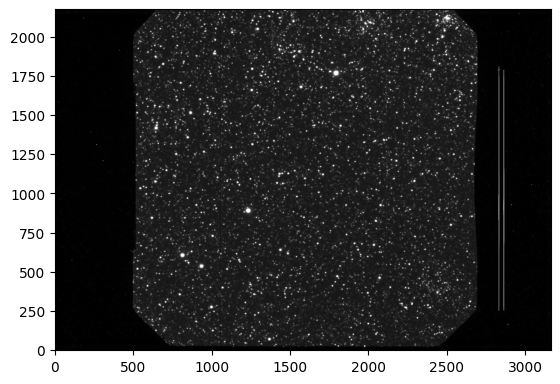

In [5]:
import matplotlib.pyplot as plt

oiiic_crop = oiiic_data
plt.imshow(oiiic_crop, cmap='gray', origin='lower', vmin=np.percentile(oiiic_crop,1), vmax=np.percentile(oiiic_crop,99.5))
plt.show()


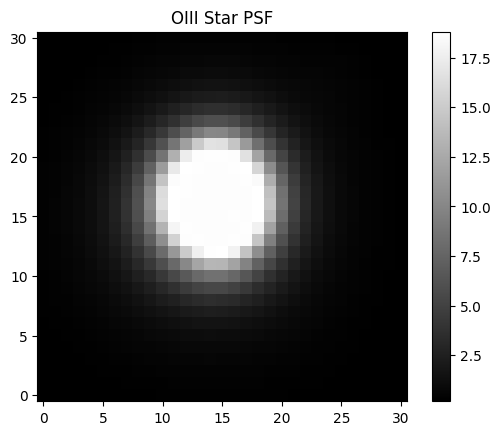

In [11]:
from astropy.nddata import Cutout2D

size = 31
star_oiii = Cutout2D(oiii_data, (1790, 1765), (size, size)).data
plt.imshow(star_oiii, origin="lower", cmap="gray", vmin=np.nanpercentile(star_oiii, 5), vmax=np.nanpercentile(star_oiii, 99.5))
plt.colorbar()
plt.title("OIII Star PSF")
plt.show()

In [12]:
# OIII PSF
psf_oiii = star_oiii - np.nanmedian(star_oiii)
psf_oiii[psf_oiii < 0] = 0    # reject negative values
psf_oiii = psf_oiii / np.nansum(psf_oiii)  # normalize

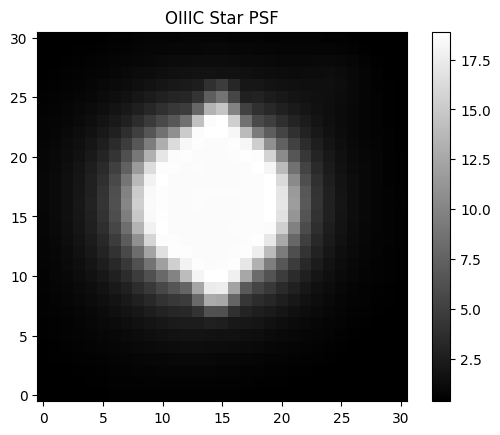

In [13]:
from astropy.nddata import Cutout2D

size = 31
star_oiiic = Cutout2D(oiiic_data, (1790, 1765), (size, size)).data
plt.imshow(star_oiiic, origin="lower", cmap="gray", vmin=np.nanpercentile(star_oiiic, 5), vmax=np.nanpercentile(star_oiiic, 99.5))
plt.colorbar()
plt.title("OIIIC Star PSF")
plt.show()

In [14]:
# OIII PSF
psf_oiiic = star_oiiic - np.nanmedian(star_oiiic)
psf_oiiic[psf_oiiic < 0] = 0    # reject negative values
psf_oiiic = psf_oiiic / np.nansum(psf_oiiic)  # normalize

In [15]:
from photutils.psf_matching import make_kernel
kernel = make_kernel(psf_oiii, psf_oiiic)